In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
path_to_file = "calibration_results.csv"
#path_to_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_run_prefactor_test_overnight/calibration_results.csv"
df = pd.read_csv(path_to_file)

In [2]:
CALIBRATION_PARAMS = {
    'referenceEPotFactor': {
        'section': 'meteoOptions',
        'key': 'referenceEPotFactor',
        'bounds': (0.5, 2),
        'initial': 1.0,
    },
    'precipitationFactor': {
        'section': 'meteoOptions',
        'key': 'precipitationFactor',
        'bounds': (0.4, 1.5),
        'initial': 1.0,
    },
    'temperatureFactor': {
        'section': 'meteoOptions',
        'key': 'temperatureFactor',
        'bounds': (0.8, 1.2),
        'initial': 1.0,
    },
    'temperatureConstant': {
        'section': 'meteoOptions',
        'key': 'temperatureConstant',
        'bounds': (-277.15, -269.15),
        'initial': -273.15,
    },
    'maximize_irrigation_threshold': {
        'section': 'landSurfaceOptions',
        'key': 'treshold_to_maximize_irrigation_surface_water',
        'bounds': (0.4, 0.6),
        'initial': 0.5,
    },
    'manningsN': {
        'section': 'routingOptions',
        'key': 'manningsN',
        'bounds': (0.005, 0.1),
        'initial': 0.04,
    },
    'multiplier_for_storCap': {
        'section': 'prefactorOptions',
        'key': 'linear_multiplier_for_storCap',
        'bounds': (0.5, 5),
        'initial': 3.0,
    },
    'multiplier_for_recessionCoeff': {
        'section': 'prefactorOptions',
        'key': 'log_10_multiplier_for_recessionCoeff',
        'bounds': (0.5, 5),
        'initial': 1.0,
    },
    'multiplier_for_kSat': {
        'section': 'prefactorOptions',
        'key': 'log_10_multiplier_for_kSat',
        'bounds': (0.5, 5),
        'initial': 3.0,
    },
}

param_config = CALIBRATION_PARAMS
n_best = 10

In [3]:
df.columns

Index(['run_tag', 'timestamp', 'objective_value', 'referenceEPotFactor',
       'precipitationFactor', 'temperatureFactor', 'temperatureConstant',
       'maximize_irrigation_threshold', 'manningsN', 'multiplier_for_storCap',
       'multiplier_for_recessionCoeff', 'multiplier_for_kSat', 'nse_Chatly',
       'kge_Chatly', 'obj_Chatly', 'nse_Garm', 'kge_Garm', 'obj_Garm',
       'nse_Uch-Kurgan', 'kge_Uch-Kurgan', 'obj_Uch-Kurgan'],
      dtype='object')

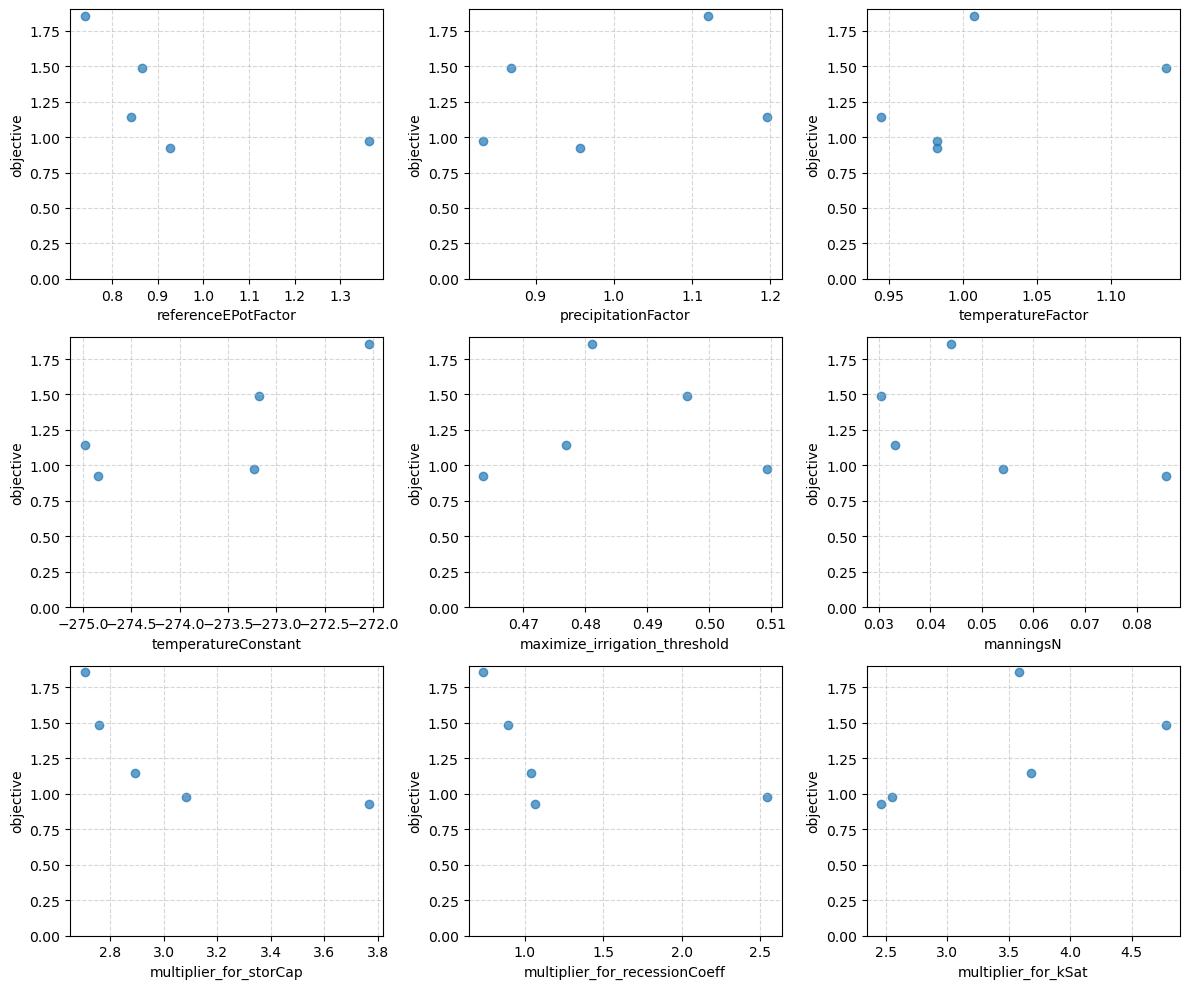

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12,10))
axes = axes.flatten()

for i, p in enumerate(param_config):
    axes[i].scatter(df[p], df["objective_value"], alpha=0.7)
    axes[i].set_xlabel(p)
    axes[i].set_ylabel("objective")
    axes[i].grid(linestyle="--", alpha=0.5)
    axes[i].set_ylim(bottom=0)

for j in range(len(param_config), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

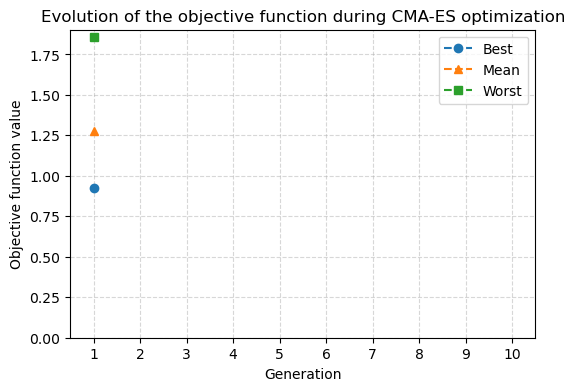

In [5]:
popsize = 6

df["generation"] = df.index // popsize

best_per_gen = df.groupby("generation")["objective_value"].min()
mean_per_gen = df.groupby("generation")["objective_value"].mean()
worst_per_gen = df.groupby("generation")["objective_value"].max()

plt.figure(figsize=(6,4))
plt.plot(best_per_gen.index+1, best_per_gen.values, linestyle="--", marker="o", label ="Best")
plt.plot(mean_per_gen.index+1, mean_per_gen.values, linestyle="--", marker="^", label="Mean")
plt.plot(worst_per_gen.index+1, worst_per_gen.values, linestyle="--", marker="s", label="Worst")

#x = list(range(1, len(best_per_gen)+1))
x = list(range(1, 11))

plt.xticks(ticks=x, labels=x)

plt.xlabel("Generation")
plt.ylabel("Objective function value")
plt.title("Evolution of the objective function during CMA-ES optimization")
plt.legend()
plt.ylim(bottom=0)
plt.xlim(left=1-0.5, right=10.5)
plt.grid(linestyle="--", alpha=0.5)

plt.show()

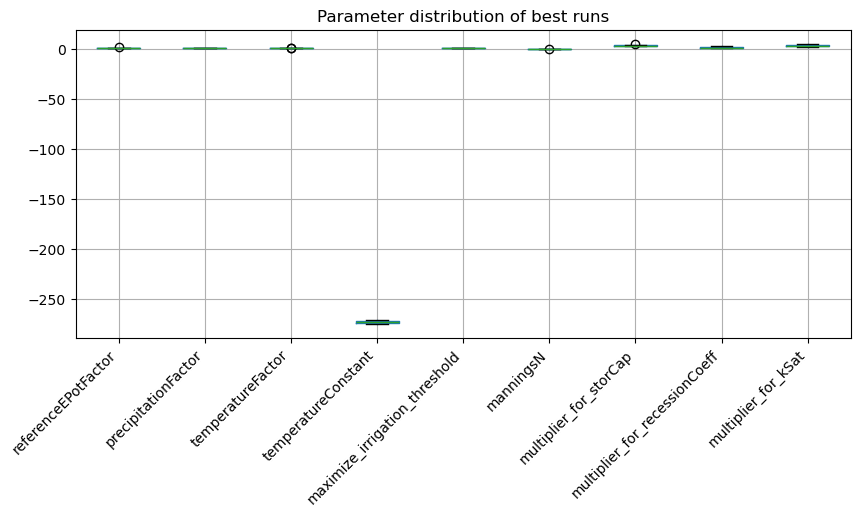

In [6]:
params = [p for p in param_config.keys() if p in df.columns]
best = df.nsmallest(n_best, "objective_value")

best[params].boxplot(figsize=(10,4))

plt.xticks(
    ticks=range(1, len(params) + 1),
    labels=params,
    rotation=45,
    ha="right",
)

plt.title("Parameter distribution of best runs")
plt.show()

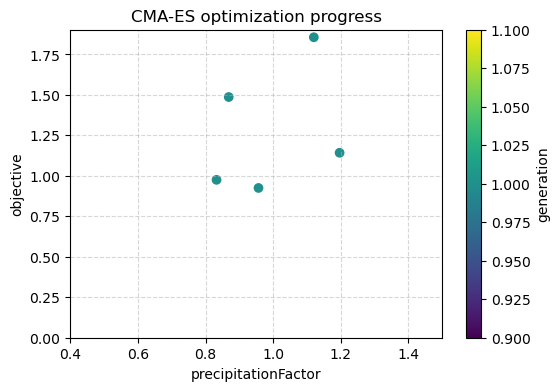

In [7]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    df["precipitationFactor"],
    df["objective_value"],
    c=df["generation"]+1,
)

plt.colorbar(sc, label="generation")
plt.xlabel("precipitationFactor")
plt.ylabel("objective")
plt.grid(linestyle="--", alpha=0.5)
plt.ylim(bottom=0)
plt.xlim(0.4, 1.5)

plt.title("CMA-ES optimization progress")

plt.show()

In [8]:
# create scaled dataframe
df_scaled = df.copy()


for param, cfg in param_config.items():
    if param not in df.columns:
        continue
    lower, upper = cfg["bounds"]
    df_scaled[f"{param}_scaled"] = (df[param] - lower) / (upper - lower)

df_scaled.head()

,run_tag,timestamp,objective_value,referenceEPotFactor,precipitationFactor,temperatureFactor,temperatureConstant,maximize_irrigation_threshold,manningsN,multiplier_for_storCap,...,generation,referenceEPotFactor_scaled,precipitationFactor_scaled,temperatureFactor_scaled,temperatureConstant_scaled,maximize_irrigation_threshold_scaled,manningsN_scaled,multiplier_for_storCap_scaled,multiplier_for_recessionCoeff_scaled,multiplier_for_kSat_scaled
0,84180232,2026-03-18 21:56:26,1.856221,0.739844,1.120184,1.007241,-272.040138,0.481088,0.044132,2.704441,...,0,0.159896,0.654713,0.518103,0.638733,0.405441,0.411918,0.489876,0.051728,0.684679
1,fd733e59,2026-03-18 21:56:26,0.975362,1.362720,0.832493,0.982493,-273.230247,0.509408,0.054201,3.082053,...,0,0.575146,0.393175,0.456232,0.489969,0.547042,0.517903,0.573790,0.454373,0.455627
2,bc765a11,2026-03-18 21:56:26,1.142599,0.841781,1.196381,0.944790,-274.984817,0.476882,0.033267,2.894014,...,0,0.227854,0.723983,0.361974,0.270648,0.384408,0.297544,0.532003,0.120043,0.706812
3,620afdae,2026-03-18 22:33:17,0.925244,0.927765,0.956547,0.982847,-274.848963,0.463439,0.085654,3.767062,...,0,0.285176,0.505951,0.457119,0.287630,0.317197,0.848987,0.726014,0.125513,0.436226
4,53e18639,2026-03-18 22:33:17,1.486919,0.866237,0.868531,1.137288,-273.181925,0.496449,0.030520,2.759919,...,0,0.244158,0.425937,0.843220,0.496009,0.482244,0.268634,0.502204,0.086834,0.950286


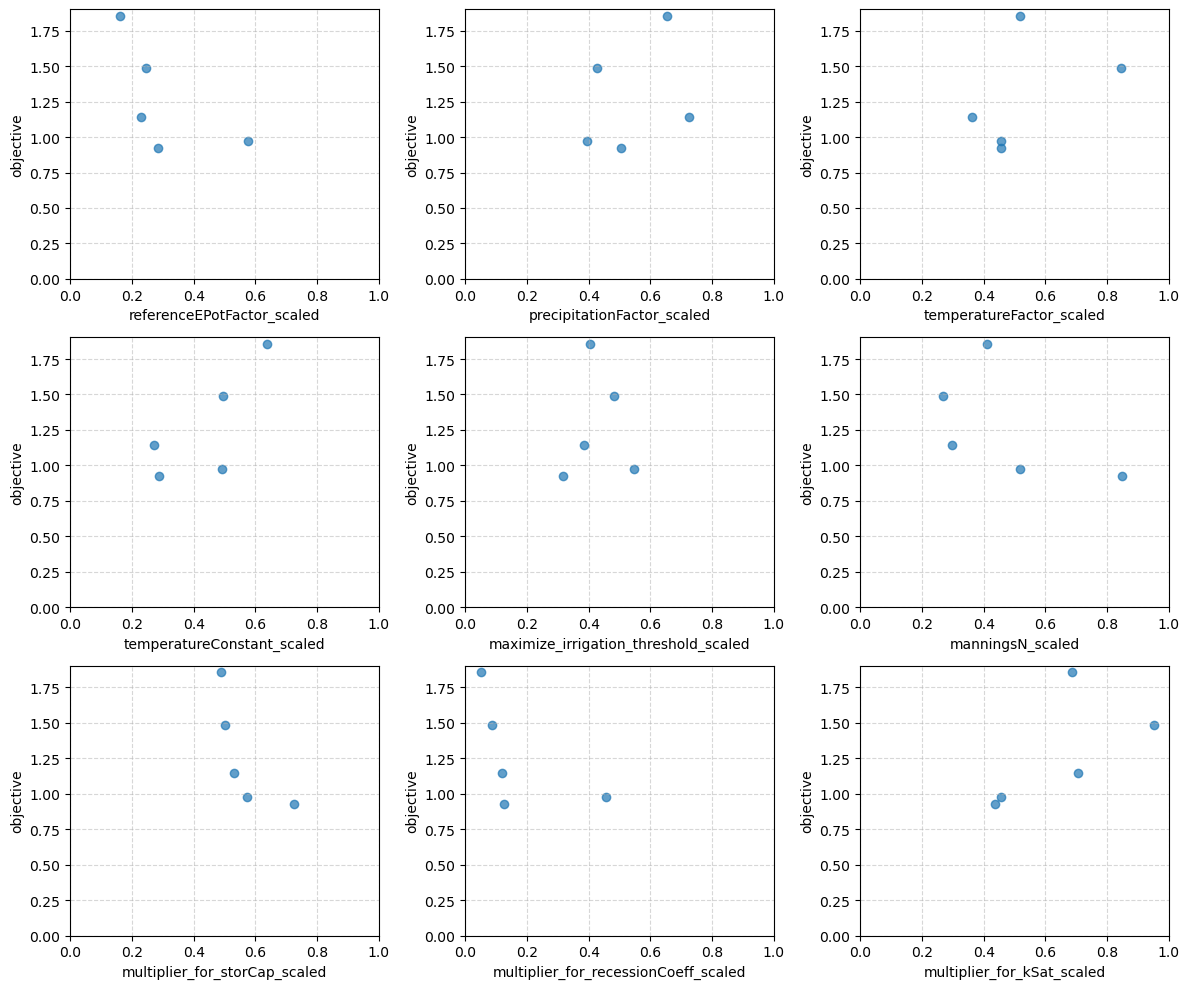

In [9]:

scaled_params = [p + "_scaled" for p in param_config.keys()]

fig, axes = plt.subplots(3,3, figsize=(12,10))
axes = axes.flatten()

for i, p in enumerate(scaled_params):
    axes[i].scatter(df_scaled[p], df_scaled["objective_value"], alpha=0.7)
    axes[i].set_xlabel(p)
    axes[i].set_ylabel("objective")
    axes[i].grid(linestyle="--", alpha=0.5)
    axes[i].set_xlim(0,1)
    axes[i].set_ylim(bottom=0)

for j in range(len(scaled_params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

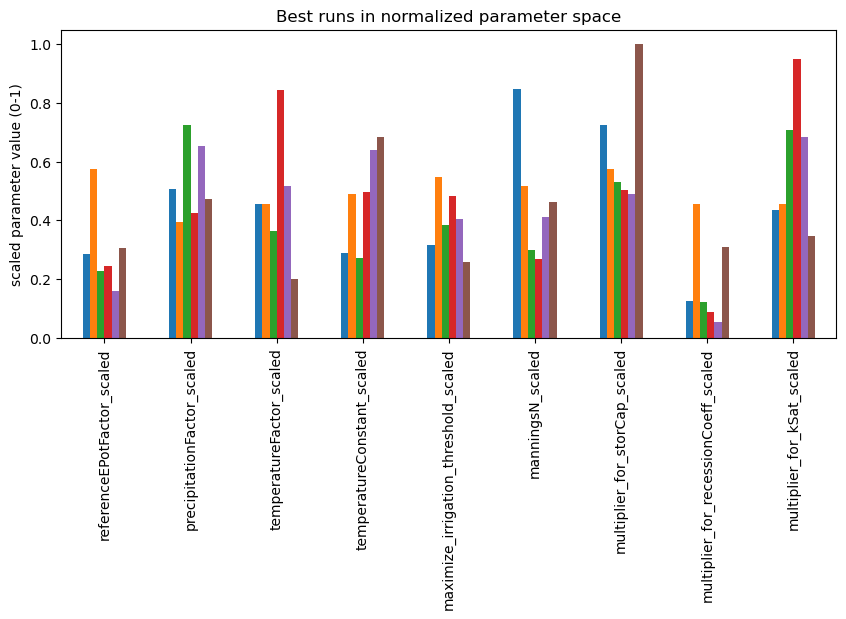

In [10]:

best = df_scaled.nsmallest(n_best, "objective_value")

best[[p + "_scaled" for p in param_config]].T.plot(
    kind="bar",
    legend=False,
    figsize=(10,4)
)

plt.ylabel("scaled parameter value (0-1)")
plt.title("Best runs in normalized parameter space")
plt.show()

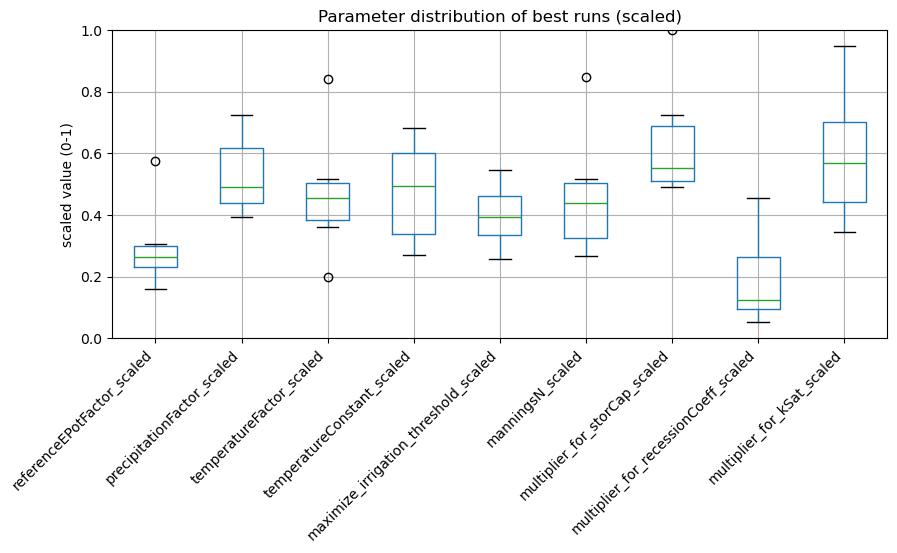

In [11]:
best = df_scaled.nsmallest(n_best, "objective_value")

scaled_params = [p + "_scaled" for p in param_config]

best[scaled_params].boxplot(figsize=(10,4))

plt.xticks(
    ticks=range(1, len(scaled_params) + 1),
    labels=scaled_params,
    rotation=45,
    ha="right",
)
plt.ylim(0, 1)

plt.ylabel("scaled value (0-1)")
plt.title("Parameter distribution of best runs (scaled)")
plt.show()

In [12]:
# # Select only good runs (important!)
df_good = df[df["objective_value"] <= 3]

# corrs = {}

# for p in param_config:
#     corrs[p] = df_good[p].corr(df_good["objective_value"])

# # Sort by absolute importance
# corrs = pd.Series(corrs).sort_values(key=lambda x: abs(x), ascending=False)

# print(corrs)

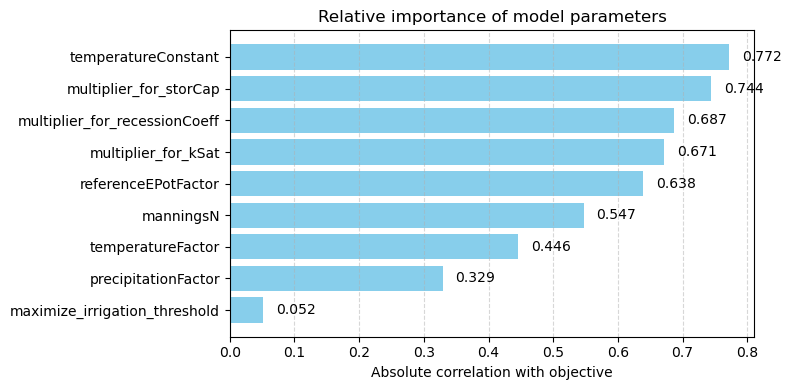

In [13]:
log_params = {
    "multiplier_for_kSat",
    "multiplier_for_recessionCoeff",
    # add all multipliers applied in log-space
}

# example in correlation loop:


corrs = {}
for p in param_config:
    if p in df_good.columns:
        x = np.log10(df_good[p]) if p in log_params else df_good[p]
        corrs[p] = x.corr(df_good["objective_value"])
        #corrs[p] = df_good[p].corr(df_good["objective_value"])

corrs = pd.Series(corrs).dropna().sort_values(key=lambda x: x.abs(), ascending=False)

# params and absolute correlations
params = corrs.index.tolist()
values = corrs.abs().tolist()



plt.figure(figsize=(8,4))
plt.barh(params, values, color="skyblue")
plt.xlabel("Absolute correlation with objective")
plt.title("Relative importance of model parameters")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(values):
    plt.text(v + 0.02, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

In [14]:
corrs

temperatureConstant              0.772167
multiplier_for_storCap          -0.744329
multiplier_for_recessionCoeff   -0.686746
multiplier_for_kSat              0.670672
referenceEPotFactor             -0.638222
manningsN                       -0.546768
temperatureFactor                0.446211
precipitationFactor              0.328932
maximize_irrigation_threshold    0.051943
dtype: float64